# Notebook 03 — Feature Engineering
**Prepared for the Machine Learning course.**

### References
- Lunor, S.B.R. et al. (2023). Machine Learning Approach for Pump Price Prediction for the Philippines Post COVID-19. *CET*, 103.
- Wen, D. et al. (2025). Forecasting gasoline prices: New evidence based on the rocket and feather hypothesis. *Energy*, 335.
- Borenstein, Cameron & Gilbert (1997). Do Gasoline Prices Respond Asymmetrically to Crude Oil Price Changes? *QJE*, 112(1).
- Hamilton, J.D. (1989). A New Approach to the Economic Analysis of Nonstationary Time Series. *Econometrica*, 57(2).

### EDA decisions implemented here

| # | EDA Finding | Decision |
|---|---|---|
| 1 | All series I(1) — non-stationary in levels (Section 4) | Model on **log returns (Δlog price)**, not levels — addresses AR(1) trap |
| 2 | Brent–WTI r = 0.991 (Section 3) | Drop WTI — done in NB02 |
| 3 | CCF MOPS→diesel peaks Lag 1, noise at Lag 4 (Section 5) | Lags 1–4 on crude/FX features |
| 4 | Lag-0 same-week indexing — data leakage (Section 5) | Lag 0 forbidden on all market features |
| 5 | Own-price autocorr ≈ 0.97 (Section 6) | Own-price lags 1–4 unconditionally included |
| 6 | RFH asymmetry confirmed (Section 7) | Split Brent change into pos/neg (Wen et al. 2025) |
| 7 | Markov σ² ratio 32x — 2 clear regimes (Section 9) | `markov_prob_highvol` as continuous regime feature |
| 8 | Prof: momentum is the missing feature | `diesel_mom_1w`, `diesel_mom_2w`, `brent_mom_1w` |
| 9 | Prof: features explain levels not changes | WoW % changes for Brent and USD/PHP |
| 10 | Prof: VIF on final feature set before modeling | VIF screen in Section 8 |

### On the I(1) / stationarity question
The ADF test in NB02 confirmed all series are **I(1)** — integrated of order one. This means:
- Modeling price **levels** directly risks spurious regression (the model learns the trend, not the signal)
- The fix is to model **Δlog(price)** — the log return — which is stationary by construction
- This directly addresses the AR(1) trap the professor identified: *"your model is just copying last week's price"*
- At prediction time, convert back: `price_t = price_{t-1} × exp(Δlog_price_hat)`

**We model diesel only in this notebook.** The per-product extension (ron91, ron95, ron97) follows the same pipeline — feature sets differ only in own-price lags and excise column.


---
## Section 1 — Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.transforms as transforms
import seaborn as sns
import json, os

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import t as t_dist

os.makedirs('data/final', exist_ok=True)

# ── Global plot style (matches EDA notebook) ──────────────────────────────
FIGSIZE_WIDE = (14, 4)
FIGSIZE_MED  = (14, 7)
FIGSIZE_TALL = (14, 11)
FONT_TITLE   = 12
FONT_AXIS    = 10
FONT_TICK    = 9
FONT_LEGEND  = 9

plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

CRISIS_BANDS = [
    ('2020-03-09', '2020-06-15', '#4e79a7', 'COVID-19'),
    ('2022-02-24', '2022-12-31', '#e15759', 'Russia–Ukraine'),
    ('2026-01-01', '2026-04-30', '#f28e2b', 'OPEC+/Tariff Shock'),
]

def shade_crises(ax, alpha=0.12):
    for start, end, color, label in CRISIS_BANDS:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   color=color, alpha=alpha, label=label)

# ── Constants ─────────────────────────────────────────────────────────────
PRIMARY_TARGET = 'diesel'
ALL_PRODUCTS   = ['diesel', 'diesel_plus', 'kerosene', 'ron100', 'ron91', 'ron95', 'ron97']
LAGS           = [1, 2, 3, 4]


---
## Section 2 — Load & Target Construction

We load from `master_weekly_with_regimes.parquet` (Notebook 02 output). The first thing we do is construct the **modeling target**: `diesel_log_ret` — the week-on-week log return of diesel price. This is what all models in Notebook 04 will predict. Predictions are then inverted back to peso levels for MAPE reporting.


In [2]:
df = pd.read_parquet('data/final/master_pre_engineered.parquet')

print(f'Loaded  : {df.shape}')
print(f'Dates   : {df.index.min().date()} → {df.index.max().date()}')
print(f'Columns : {df.columns.tolist()}')


Loaded  : (373, 34)
Dates   : 2018-02-13 → 2026-04-28
Columns : ['usd_php_mean', 'brent_mean', 'mops_gasoil_mean', 'mops_rbob_mean', 'dubai_close', 'cpi_value', 'rub_usd_mean', 'vix_mean', 'GPR_AI', 'GPR_OIL', 'GPR_OIL_MiddleEast', 'GPR_OIL_Russia', 'GPR_NONOIL', 'ovx_mean', 'diesel', 'diesel_plus', 'kerosene', 'ron100', 'ron91', 'ron95', 'ron97', 'diesel_chg', 'markov_prob_highvol', 'markov_regime_flag', 'd_covid', 'd_ukraine', 'd_iran26', 'anomaly_flag', 'crisis_intensity', 'iso_score', 'iso_flag', 'pelt_regime', 'ovx_z', 'gpr_z']


In [26]:
# ── Null fill on target columns ───────────────────────────────────────────
available_targets = [c for c in ALL_PRODUCTS if c in df.columns]
df[available_targets] = df[available_targets].ffill()

# ── Construct the modeling target: diesel log return ──────────────────────
# This is the stationary transformation of the I(1) diesel price series.
# EDA Section 4 confirmed: diesel levels are non-stationary (ADF p > 0.05),
# first-differences are stationary (ADF p < 0.01).
# Log returns are preferred over raw differences: they are symmetric,
# approximately normally distributed, and allow clean back-transformation.
df['diesel_log_ret'] = np.log(df[PRIMARY_TARGET] / df[PRIMARY_TARGET].shift(1))

# Sanity check: log return should be ~zero mean, small std
print('Diesel log return summary:')
print(df['diesel_log_ret'].describe().round(6))
print()
print(f'Mean  ≈ 0 expected (weekly avg change near zero): {df["diesel_log_ret"].mean():.6f}')
print(f'Std   ≈ 0.01–0.03 for administered fuel prices  : {df["diesel_log_ret"].std():.6f}')


Diesel log return summary:
count    368.000000
mean       0.001905
std        0.042646
min       -0.224966
25%       -0.014623
50%        0.000379
75%        0.016802
max        0.334706
Name: diesel_log_ret, dtype: float64

Mean  ≈ 0 expected (weekly avg change near zero): 0.001905
Std   ≈ 0.01–0.03 for administered fuel prices  : 0.042646


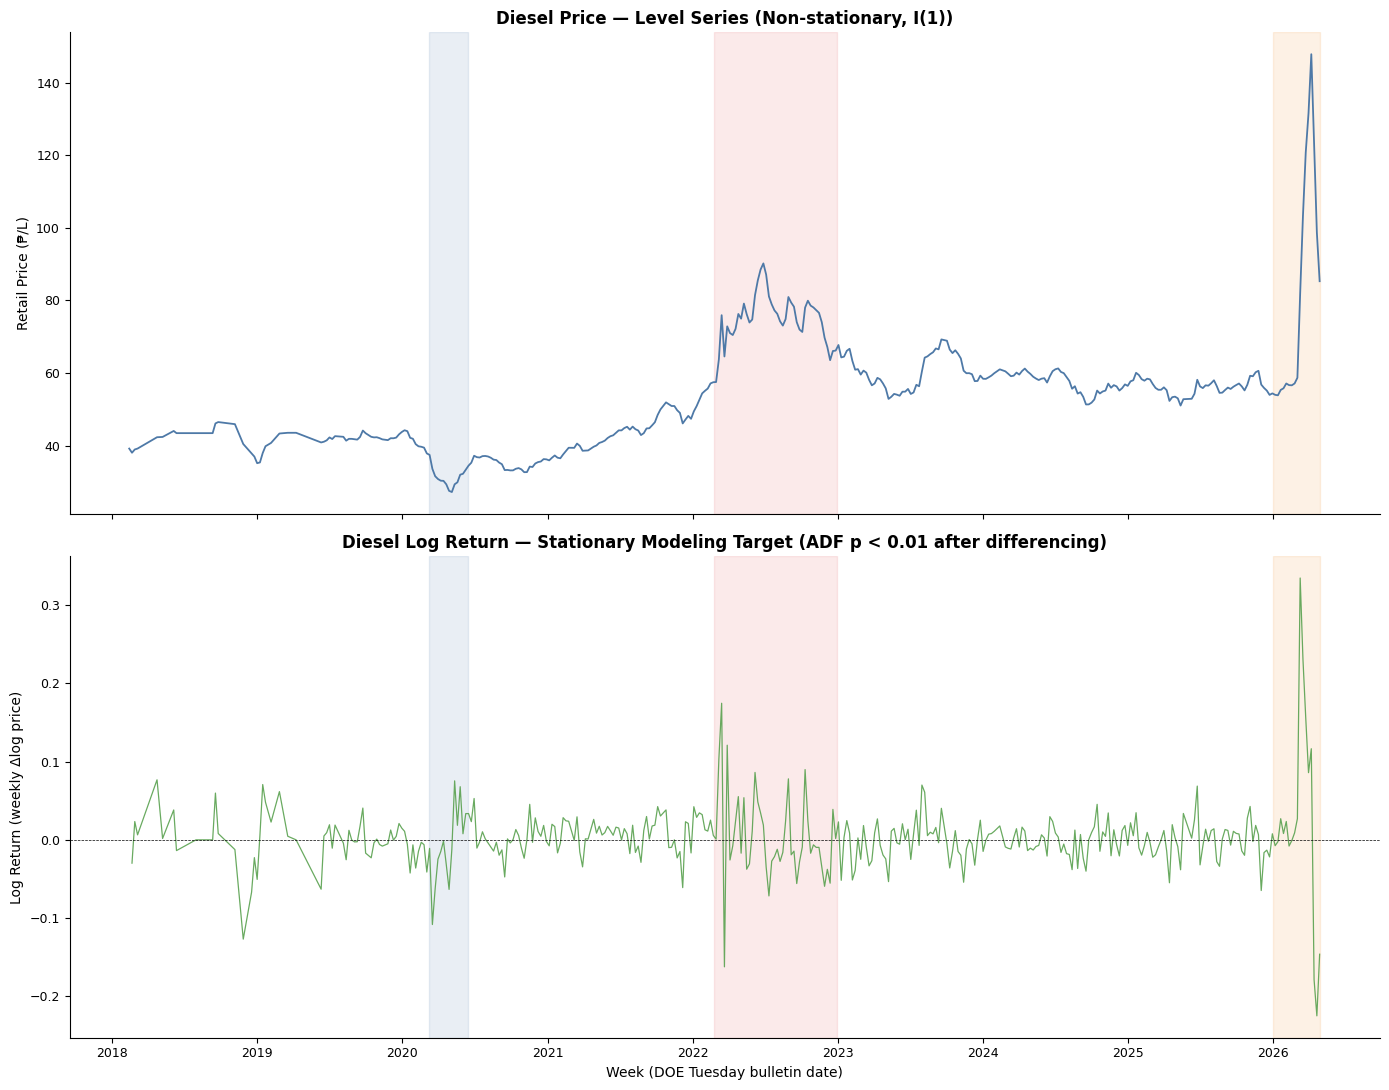

→ Models in NB04 predict diesel_log_ret.
  Back-transform: price_t = price_{t-1} × exp(predicted_log_ret)
  MAPE and RMSE reported in ₱/L after back-transformation.


In [4]:
# ── Visualize: levels vs log returns ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE_TALL, sharex=True)
plt.subplots_adjust(hspace=0.08)

ax = axes[0]
ax.plot(df.index, df[PRIMARY_TARGET], color='#4e79a7', linewidth=1.3)
shade_crises(ax)
ax.set_ylabel('Retail Price (₱/L)', fontsize=FONT_AXIS)
ax.set_title('Diesel Price — Level Series (Non-stationary, I(1))',
             fontsize=FONT_TITLE, fontweight='bold')

ax = axes[1]
ax.plot(df['diesel_log_ret'].dropna().index,
        df['diesel_log_ret'].dropna(),
        color='#59a14f', linewidth=0.9, alpha=0.9)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
shade_crises(ax)
ax.set_ylabel('Log Return (weekly Δlog price)', fontsize=FONT_AXIS)
ax.set_xlabel('Week (DOE Tuesday bulletin date)', fontsize=FONT_AXIS)
ax.set_title('Diesel Log Return — Stationary Modeling Target (ADF p < 0.01 after differencing)',
             fontsize=FONT_TITLE, fontweight='bold')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(labelsize=FONT_TICK)

plt.tight_layout()
plt.show()

print('→ Models in NB04 predict diesel_log_ret.')
print('  Back-transform: price_t = price_{t-1} × exp(predicted_log_ret)')
print('  MAPE and RMSE reported in ₱/L after back-transformation.')


---
## Section 3 — Derived Features

All derived features are constructed here before lagging. Every feature has a direct economic motivation — nothing is added for the sake of it.

| Feature | Economic motivation | EDA / Prof basis |
|---|---|---|
| `crack_spread` | Refining margin: when MOPS–Brent widens, pump prices rise beyond crude alone | Derived from EDA correlation structure |
| `brent_chg_pos` / `brent_chg_neg` | Rockets vs feathers — asymmetric pass-through | EDA Section 7, Wen et al. (2025) |
| `diesel_mom_1w` / `2w` | Own-price momentum — "price tomorrow = price today + how fast it's moving" | Prof priority request |
| `brent_mom_1w` / `2w` | Upstream momentum | Prof priority request |
| `brent_pct_1w` / `usdphp_pct_1w` | Rate-of-change signals — explain *movements* not levels | Prof: features explain levels not changes |
| `brent_vol_4w` | Market uncertainty — vol reflects uncertainty not direction | Prof approved; 4-week window per prof spec |
| `brent_log_ret` | Brent log return — stationary upstream signal | Consistent with diesel target construction |

**Note on MOPS:** Excluded from all direct model features per professor — MOPS is the literal formula input oil companies use to compute pump prices (data leakage). `crack_spread` carries the MOPS-Brent relationship without leakage since it uses Brent as the reference.


In [5]:
# ── Crack spread (refining margin) ────────────────────────────────────────
if 'brent_mean' in df.columns and 'mops_gasoil_mean' in df.columns:
    df['crack_spread'] = df['brent_mean'] - df['mops_gasoil_mean']

# ── Asymmetric Brent changes — RFH (Wen et al. 2025) ─────────────────────
brent_chg           = df['brent_mean'].diff()
df['brent_chg_pos'] = brent_chg.clip(lower=0)
df['brent_chg_neg'] = brent_chg.clip(upper=0)

# ── Momentum features (professor priority) ────────────────────────────────
df['diesel_mom_1w'] = df[PRIMARY_TARGET].diff(1)
df['diesel_mom_2w'] = df[PRIMARY_TARGET].diff(2)
df['brent_mom_1w']  = df['brent_mean'].diff(1)
df['brent_mom_2w']  = df['brent_mean'].diff(2)

# ── WoW % change — rate of change, not level ──────────────────────────────
df['brent_pct_1w']  = df['brent_mean'].pct_change(1) * 100
df['usdphp_pct_1w'] = df['usd_php_mean'].pct_change(1) * 100

# ── Brent log return (stationary upstream signal) ─────────────────────────
df['brent_log_ret'] = np.log(df['brent_mean'] / df['brent_mean'].shift(1))

# ── Realized volatility — 4-week rolling (prof specified window) ──────────
df['brent_vol_4w']  = df['brent_log_ret'].rolling(4).std() * np.sqrt(52)
df['brent_vol_12w'] = df['brent_log_ret'].rolling(12).std() * np.sqrt(52)

# Add to Section 3 derived features
df['dubai_log_ret'] = np.log(df['dubai_close'] / df['dubai_close'].shift(1))
df['cpi_log_ret']   = np.log(df['cpi_value']   / df['cpi_value'].shift(1))

# ── Summary ───────────────────────────────────────────────────────────────
derived = ['crack_spread','brent_chg_pos','brent_chg_neg',
           'diesel_mom_1w','diesel_mom_2w','brent_mom_1w','brent_mom_2w',
           'brent_pct_1w','usdphp_pct_1w','brent_log_ret',
           'brent_vol_4w','brent_vol_12w']
print('Derived feature summary:')
print(df[derived].describe().round(4))


Derived feature summary:
       crack_spread  brent_chg_pos  brent_chg_neg  diesel_mom_1w  \
count      373.0000       372.0000       372.0000       372.0000   
mean       -18.4749         1.3604        -1.2268         0.1239   
std         13.6624         2.2358         2.2666         3.4061   
min        -93.7505         0.0000       -13.1960       -24.9000   
25%        -22.3324         0.0000        -1.5540        -0.7444   
50%        -15.0944         0.3630         0.0000         0.0213   
75%        -10.8342         2.1645         0.0000         0.7919   
max         -1.8045        21.4420         0.0000        23.3250   

       diesel_mom_2w  brent_mom_1w  brent_mom_2w  brent_pct_1w  usdphp_pct_1w  \
count       371.0000      372.0000      371.0000      372.0000       372.0000   
mean          0.2878        0.1335        0.2528        0.3170         0.0451   
std           5.7340        3.6719        5.7028        5.6677         0.6695   
min         -49.1000      -13.1960    

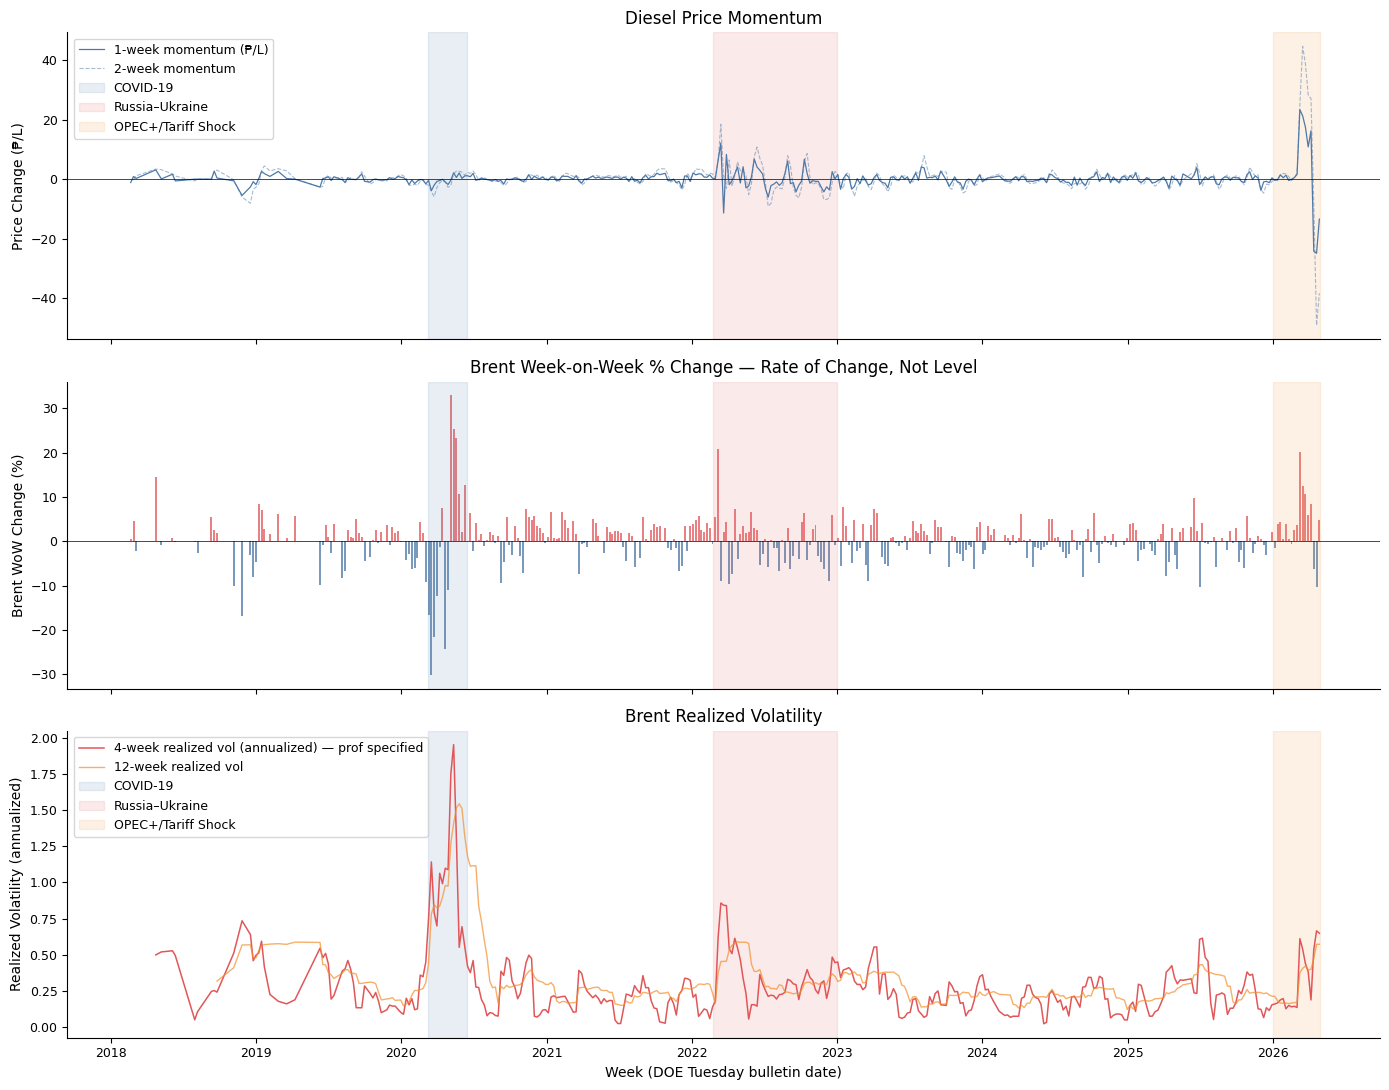

In [6]:
# ── Visualize: momentum and vol ───────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=FIGSIZE_TALL, sharex=True)
plt.subplots_adjust(hspace=0.08)

# Panel 1: Diesel momentum
ax = axes[0]
ax.plot(df.index, df['diesel_mom_1w'], color='#4e79a7', linewidth=0.9,
        label='1-week momentum (₱/L)')
ax.plot(df.index, df['diesel_mom_2w'], color='#4e79a7', linewidth=0.8,
        linestyle='--', alpha=0.5, label='2-week momentum')
ax.axhline(0, color='black', linewidth=0.5)
shade_crises(ax)
ax.set_ylabel('Price Change (₱/L)', fontsize=FONT_AXIS)
ax.set_title('Diesel Price Momentum')
ax.legend(loc='upper left', fontsize=FONT_LEGEND)

# Panel 2: Brent WoW % change
ax = axes[1]
colors_bar = ['#e15759' if v >= 0 else '#4e79a7'
              for v in df['brent_pct_1w'].fillna(0)]
ax.bar(df.index, df['brent_pct_1w'].fillna(0),
       color=colors_bar, width=5, alpha=0.75)
ax.axhline(0, color='black', linewidth=0.5)
shade_crises(ax)
ax.set_ylabel('Brent WoW Change (%)', fontsize=FONT_AXIS)
ax.set_title('Brent Week-on-Week % Change — Rate of Change, Not Level')

# Panel 3: Realized vol
ax = axes[2]
ax.plot(df.index, df['brent_vol_4w'],  color='#e15759', linewidth=1.1,
        label='4-week realized vol (annualized) — prof specified')
ax.plot(df.index, df['brent_vol_12w'], color='#f28e2b', linewidth=1.0,
        alpha=0.7, label='12-week realized vol')
shade_crises(ax)
ax.set_ylabel('Realized Volatility (annualized)', fontsize=FONT_AXIS)
ax.set_xlabel('Week (DOE Tuesday bulletin date)', fontsize=FONT_AXIS)
ax.set_title('Brent Realized Volatility')
ax.legend(loc='upper left', fontsize=FONT_LEGEND)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(labelsize=FONT_TICK)

plt.tight_layout()
plt.show()


---
## Section 4 — Excise Tax Step Function (TRAIN Law, RA 10963)

Deterministic step changes not learnable from price data. Encoding explicitly prevents the model from treating the 2018–2020 annual price jumps as unexplained shocks.


In [7]:
def get_excise(date, fuel_type):
    """RA 10963 TRAIN Law excise tax per liter. Tranche 1: 2018 | 2: 2019 | 3: 2020+"""
    schedules = {
        'gasoline': {2018: 7.00, 2019: 9.00, 2020: 10.00},
        'diesel':   {2018: 2.65, 2019: 4.50, 2020: 6.00},
        'kerosene': {2018: 1.00, 2019: 3.00, 2020: 5.00},
    }
    s  = schedules[fuel_type]
    yr = date.year
    if   yr >= 2020: return s[2020]
    elif yr >= 2019: return s[2019]
    elif yr >= 2018: return s[2018]
    else:            return 0.0

df['excise_diesel']   = [get_excise(d, 'diesel')   for d in df.index]
df['excise_gasoline'] = [get_excise(d, 'gasoline') for d in df.index]
df['excise_kerosene'] = [get_excise(d, 'kerosene') for d in df.index]

EXCISE_MAP = {
    'diesel': 'excise_diesel', 'diesel_plus': 'excise_diesel',
    'kerosene': 'excise_kerosene',
    'ron91': 'excise_gasoline', 'ron95': 'excise_gasoline',
    'ron97': 'excise_gasoline', 'ron100': 'excise_gasoline',
}

print('Diesel excise by year (step: 2.65 → 4.50 → 6.00):')
print(df.groupby(df.index.year)['excise_diesel'].first().to_string())


Diesel excise by year (step: 2.65 → 4.50 → 6.00):
2018    2.65
2019    4.50
2020    6.00
2021    6.00
2022    6.00
2023    6.00
2024    6.00
2025    6.00
2026    6.00


---
## Section 5 — Lag Features

**Lag logic:**
- Market features (Brent, FX, vol, momentum): lags 1–4. Lag 0 forbidden — current-week values are not known before Tuesday's announcement.
- Own-price lags: lags 1–4 unconditionally (autocorr ≈ 0.97, EDA Section 6).
- Regime features (Markov prob, crisis dummies): lag 1 only — we don't need 4 lags of a slowly-moving probability.
- Momentum and WoW % change: already first-differences. Still lagged by 1 for causal ordering.

**Diesel-only scope:** We construct features for diesel only. Per-product extension in NB04 follows the same structure with own-price lags swapped.


In [8]:
# ── Base market features to lag (MOPS excluded — professor: data leakage) ─
BASE_LAG_FEATURES = [c for c in [
    'brent_mean', 'dubai_close',
    'usd_php_mean', 'cpi_value',
    'crack_spread',
    'brent_chg_pos', 'brent_chg_neg',
    'brent_log_ret',
    'brent_pct_1w', 'usdphp_pct_1w',
    'diesel_mom_1w', 'diesel_mom_2w',
    'brent_mom_1w',  'brent_mom_2w',
    'brent_vol_4w',  'brent_vol_12w',
    'ovx_mean', 'GPR_OIL',
] if c in df.columns]

# Regime features: lag 1 only
REGIME_FEATURES = [c for c in [
    'markov_prob_highvol', 'd_covid', 'd_ukraine',
] if c in df.columns]

# Own-price lags: diesel only (diesel_log_ret and level)
OWN_PRICE_FEATURES = [c for c in [
    PRIMARY_TARGET, 'diesel_log_ret'
] if c in df.columns]

print(f'Base market features to lag (lags 1–4): {len(BASE_LAG_FEATURES)}')
print(BASE_LAG_FEATURES)
print(f'\nRegime features to lag (lag 1 only)   : {len(REGIME_FEATURES)}')
print(f'\nOwn-price features to lag (lags 1–4)  : {OWN_PRICE_FEATURES}')


Base market features to lag (lags 1–4): 18
['brent_mean', 'dubai_close', 'usd_php_mean', 'cpi_value', 'crack_spread', 'brent_chg_pos', 'brent_chg_neg', 'brent_log_ret', 'brent_pct_1w', 'usdphp_pct_1w', 'diesel_mom_1w', 'diesel_mom_2w', 'brent_mom_1w', 'brent_mom_2w', 'brent_vol_4w', 'brent_vol_12w', 'ovx_mean', 'GPR_OIL']

Regime features to lag (lag 1 only)   : 3

Own-price features to lag (lags 1–4)  : ['diesel', 'diesel_log_ret']


In [9]:
# ── Create lag columns ────────────────────────────────────────────────────
lag_cols_created = []

for col in BASE_LAG_FEATURES + OWN_PRICE_FEATURES:
    for lag in LAGS:
        new_col = f'{col}_lag{lag}'
        if new_col not in df.columns:
            df[new_col] = df[col].shift(lag)
            lag_cols_created.append(new_col)

# Regime features: lag 1 only
for col in REGIME_FEATURES:
    new_col = f'{col}_lag1'
    if new_col not in df.columns:
        df[new_col] = df[col].shift(1)
        lag_cols_created.append(new_col)

print(f'Lag columns created : {len(lag_cols_created)}')
print(f'Total df columns    : {df.shape[1]}')

# Drop first 4 rows — lag-4 NaN construction window
rows_before = len(df)
df = df.dropna(subset=['brent_mean_lag4'])
print(f'Rows dropped (lag NaN construction): {rows_before - len(df)}')
print(f'Remaining rows : {len(df)}')
print(f'Date range     : {df.index.min().date()} → {df.index.max().date()}')


Lag columns created : 83
Total df columns    : 135
Rows dropped (lag NaN construction): 4
Remaining rows : 369
Date range     : 2018-04-24 → 2026-04-28


---
## Section 6 — Candidate Feature Set for Diesel

We assemble the candidate feature set before screening. This is the full set that enters p-value testing and VIF. Own-price lags and unconditional features bypass screening.


In [10]:
# ── Unconditional features (kept regardless of p-value or VIF) ────────────
# These are motivated by professor feedback or strong economic theory
UNCONDITIONAL = [c for c in [
    # Own-price lags (autocorr ≈ 0.97 — guaranteed significant)
    *[f'{PRIMARY_TARGET}_lag{l}' for l in LAGS],
    *[f'diesel_log_ret_lag{l}' for l in LAGS],
    # Momentum (prof priority)
    *[f for f in df.columns if 'mom' in f and '_lag' in f],
    # Volatility (prof approved)
    *[f for f in df.columns if 'vol' in f and '_lag' in f],
    # WoW % changes
    *[f for f in df.columns if 'pct_1w' in f and '_lag' in f],
    # RFH asymmetric features
    *[f for f in df.columns if ('chg_pos' in f or 'chg_neg' in f) and '_lag' in f],
    # Regime features
    *[f for f in df.columns if ('markov' in f or 'covid' in f or 'ukraine' in f) and '_lag' in f],
    # Excise (deterministic — not a market signal)
    'excise_diesel',
] if c in df.columns]
UNCONDITIONAL = list(dict.fromkeys(UNCONDITIONAL))   # deduplicate

# ── Candidate lag-1 features for screening ────────────────────────────────
# lag-1 only: we screen the one-week-ahead version first
CANDIDATE_LAG1 = [f'{c}_lag1' for c in BASE_LAG_FEATURES
                  if f'{c}_lag1' in df.columns
                  and f'{c}_lag1' not in set(UNCONDITIONAL)]

print(f'Unconditional features (bypass screening): {len(UNCONDITIONAL)}')
print(f'Candidate features for p-value + VIF    : {len(CANDIDATE_LAG1)}')
print('\nCandidates:')
for c in CANDIDATE_LAG1:
    print(f'  {c}')


Unconditional features (bypass screening): 52
Candidate features for p-value + VIF    : 8

Candidates:
  brent_mean_lag1
  dubai_close_lag1
  usd_php_mean_lag1
  cpi_value_lag1
  crack_spread_lag1
  brent_log_ret_lag1
  ovx_mean_lag1
  GPR_OIL_lag1


---
## Section 7 — p-value Feature Screening (Lunor et al. 2023)

Univariate OLS of each candidate feature against **diesel log return** (the modeling target). We test against log returns — not price levels — because that is what the model predicts. Testing against levels would be trivially significant for any correlated feature due to the shared non-stationarity.

Lunor et al. (2023) applied this per product with alpha = 0.05. We follow their approach with the same threshold.


In [11]:
def pvalue_screen(df, target, candidates, alpha=0.05):
    """
    Univariate OLS p-value test. Each candidate tested independently against target.
    Matches Lunor et al. (2023) Section 2.2 methodology.
    """
    data = df[[target] + [c for c in candidates if c in df.columns]].dropna()
    y    = data[target].values
    results = []

    for feat in candidates:
        if feat not in data.columns:
            continue
        Xc    = np.column_stack([np.ones(len(data)), data[feat].values])
        beta  = np.linalg.lstsq(Xc, y, rcond=None)[0]
        resid = y - Xc @ beta
        n, k  = Xc.shape
        s2    = (resid @ resid) / (n - k)
        se    = np.sqrt(np.diag(s2 * np.linalg.inv(Xc.T @ Xc)))
        t_stat = beta / se
        p_val  = 2 * (1 - t_dist.cdf(np.abs(t_stat[1]), df=n - k))
        results.append({
            'feature':     feat,
            'beta':        round(beta[1], 5),
            'p_value':     round(p_val, 6),
            'significant': p_val < alpha,
        })

    return pd.DataFrame(results).sort_values('p_value')

# Run on diesel log return target
pval_df = pvalue_screen(df, 'diesel_log_ret', CANDIDATE_LAG1)
sig_feats = pval_df[pval_df['significant']]['feature'].tolist()

print(f'p-value screening: diesel log return target, alpha = 0.05')
print(f'Significant: {len(sig_feats)} / {len(CANDIDATE_LAG1)} candidates')
print()
print(pval_df.to_string(index=False))


p-value screening: diesel log return target, alpha = 0.05
Significant: 4 / 8 candidates

           feature     beta  p_value  significant
brent_log_ret_lag1  0.36577 0.000000         True
      GPR_OIL_lag1  0.00003 0.001618         True
 crack_spread_lag1  0.00037 0.026396         True
  dubai_close_lag1  0.00026 0.028284         True
 usd_php_mean_lag1 -0.00062 0.323644        False
     ovx_mean_lag1  0.00003 0.795038        False
   brent_mean_lag1  0.00002 0.876540        False
    cpi_value_lag1 -0.00001 0.950079        False


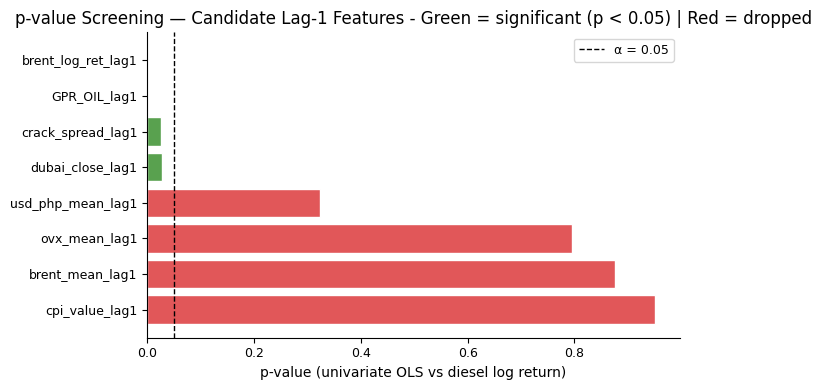

Significant features: ['brent_log_ret_lag1', 'GPR_OIL_lag1', 'crack_spread_lag1', 'dubai_close_lag1']
Dropped features    : ['usd_php_mean_lag1', 'ovx_mean_lag1', 'brent_mean_lag1', 'cpi_value_lag1']


In [12]:
# ── p-value visualisation ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, max(4, len(pval_df) * 0.38)))

colors_p = ['#59a14f' if s else '#e15759' for s in pval_df['significant']]
ax.barh(pval_df['feature'][::-1], pval_df['p_value'][::-1],
        color=colors_p[::-1], edgecolor='white')
ax.axvline(0.05, color='black', linestyle='--', linewidth=1.0, label='α = 0.05')

ax.set_xlabel('p-value (univariate OLS vs diesel log return)', fontsize=FONT_AXIS)
ax.set_title('p-value Screening — Candidate Lag-1 Features - Green = significant (p < 0.05) | Red = dropped')
ax.legend(fontsize=FONT_LEGEND)
ax.tick_params(labelsize=FONT_TICK)
plt.tight_layout()
plt.show()

print(f'Significant features: {sig_feats}')
print(f'Dropped features    : {pval_df[~pval_df["significant"]]["feature"].tolist()}')


---
## Section 8 — Variance Inflation Factor (VIF) Screen

**Professor's explicit request.** VIF measures how much a feature's variance is inflated by collinearity with other features. VIF > 10 = problematic; VIF > 5 = monitor.

VIF is complementary to p-value testing: p-value tests each feature against the **target**, VIF tests each feature against **all other features**. A feature can be individually significant (low p) but still redundant with another feature (high VIF). High-VIF crude features will be handled by PCA in Section 9.

We run VIF on the **p-value-selected + unconditional** set — the full feature set that would enter modeling without PCA.


In [13]:
# Assemble the full pre-PCA feature set for VIF
full_feature_set_pre_pca = list(dict.fromkeys(
    UNCONDITIONAL + sig_feats
))
full_feature_set_pre_pca = [f for f in full_feature_set_pre_pca if f in df.columns]

X_vif    = df[full_feature_set_pre_pca].dropna()
vif_vals = [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]

vif_df = pd.DataFrame({
    'feature': full_feature_set_pre_pca,
    'VIF':     vif_vals
}).sort_values('VIF', ascending=False)

print('VIF — Full candidate set (pre-PCA)')
print('-' * 50)
print(vif_df.to_string(index=False))
print()
high_vif = vif_df[vif_df['VIF'] > 10]
print(f'Features with VIF > 10: {len(high_vif)}')
print('→ These are candidates for PCA compression in Section 9.')


VIF — Full candidate set (pre-PCA)
--------------------------------------------------
                 feature        VIF
             diesel_lag1        inf
      diesel_mom_2w_lag3        inf
             diesel_lag2        inf
      brent_chg_pos_lag1        inf
      brent_chg_pos_lag2        inf
      brent_chg_pos_lag3        inf
      brent_chg_pos_lag4        inf
       brent_mom_2w_lag3        inf
       brent_mom_2w_lag2        inf
       brent_mom_2w_lag1        inf
       brent_mom_1w_lag4        inf
       brent_mom_1w_lag3        inf
       brent_mom_1w_lag2        inf
       brent_mom_1w_lag1        inf
      brent_chg_neg_lag1        inf
      diesel_mom_2w_lag2        inf
      diesel_mom_2w_lag1        inf
      diesel_mom_1w_lag4        inf
      diesel_mom_1w_lag3        inf
      diesel_mom_1w_lag2        inf
      diesel_mom_1w_lag1        inf
      brent_chg_neg_lag2        inf
      brent_chg_neg_lag3        inf
      brent_chg_neg_lag4        inf
             d

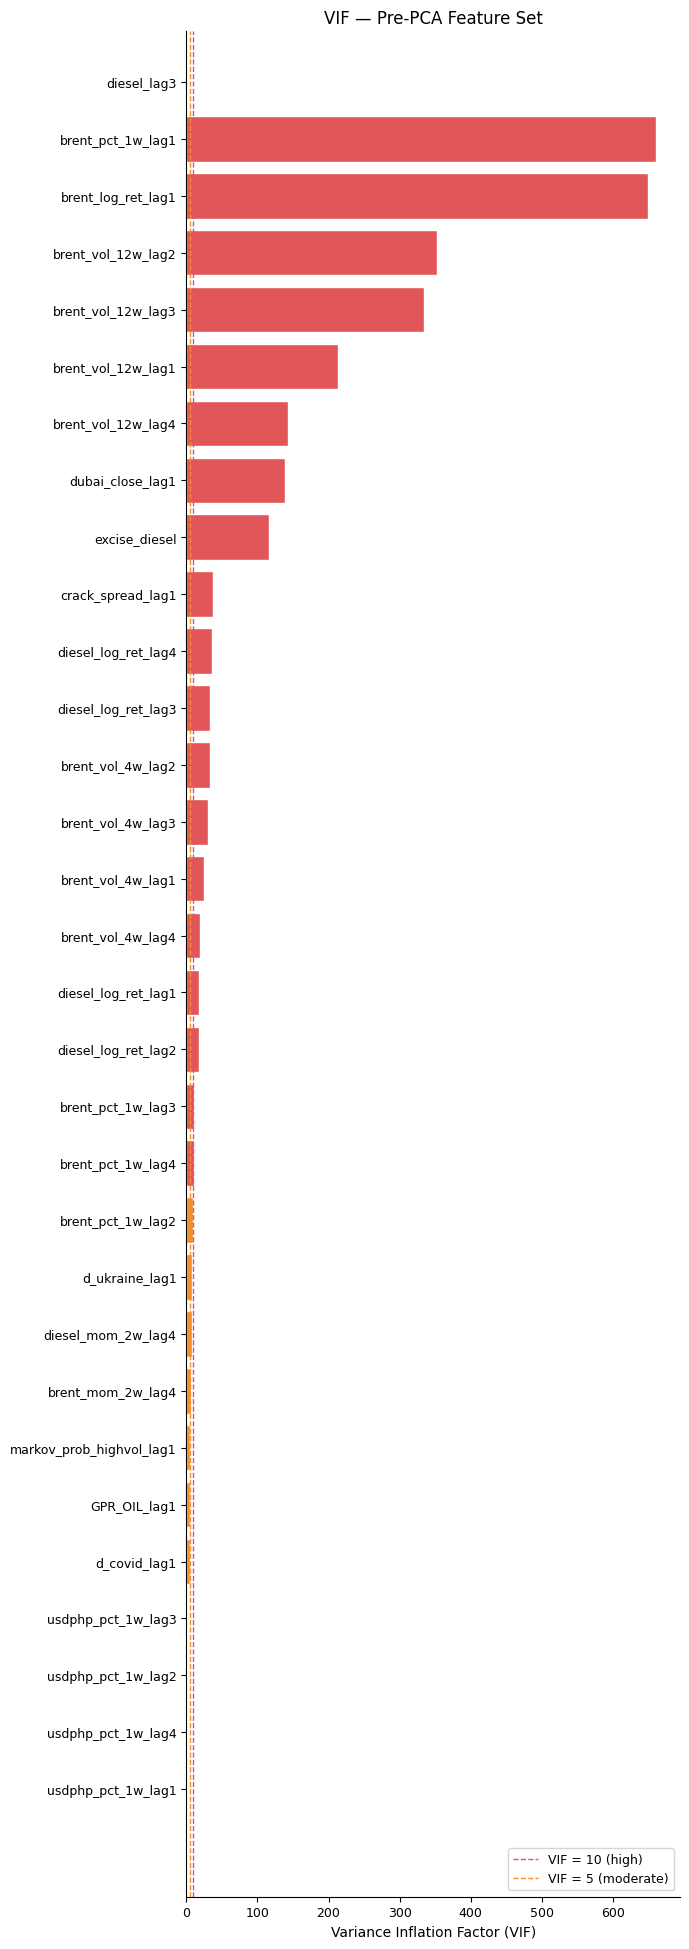

In [14]:
# ── VIF bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, max(4, len(vif_df) * 0.35)))

color_vif = ['#e15759' if v > 10 else '#f28e2b' if v > 5 else '#59a14f'
             for v in vif_df['VIF']]
ax.barh(vif_df['feature'][::-1], vif_df['VIF'][::-1],
        color=color_vif[::-1], edgecolor='white')
ax.axvline(10, color='#e15759', linestyle='--', linewidth=1.0, label='VIF = 10 (high)')
ax.axvline(5,  color='#f28e2b', linestyle='--', linewidth=1.0, label='VIF = 5 (moderate)')

ax.set_xlabel('Variance Inflation Factor (VIF)', fontsize=FONT_AXIS)
ax.set_title('VIF — Pre-PCA Feature Set')
           
ax.legend(fontsize=FONT_LEGEND)
ax.tick_params(labelsize=FONT_TICK)
plt.tight_layout()
plt.show()


---
## Section 9 — PCA on the Crude Oil Lag Block

### Why PCA here?
The VIF screen above will show that Brent and Dubai lag columns have very high VIF — they are essentially the same global crude price signal observed with a lag. Including all 8 columns (4 lags × 2 benchmarks) introduces near-redundant dimensions that confuse regularized models.

PCA rotates these 8 correlated columns into a small number of **orthogonal** components that each have a clear economic interpretation:
- **PC1** — the global crude price level (all lags move together)
- **PC2** — the crude price trend / momentum across lags (alternating sign pattern)
- **PC3+** — higher-frequency variation (diminishing interpretability)

### Prof's PCA style
We use the `plot_cum_exp_var` style from the professor's PCA notebook — cumulative variance curve with an explicit threshold line. We also use the `plot_principal_components` biplot approach: scatter of the transformed data on PC1 vs PC2, plus a loading vector diagram showing which original features contributed to each component.

### Critical leakage warning
The PCA shown here is fitted on the **full sample for documentation and interpretation only**. In Notebook 04, PCA is **re-fitted inside each CV fold on training data only**. The scaler and PCA objects must never see test data before transformation.


In [15]:
# ── Define crude lag block for PCA ────────────────────────────────────────
# Brent and Dubai lags 1-4. crack_spread lags included — it carries the
# MOPS-Brent spread signal. Other features are NOT put through PCA — they
# are change/momentum signals with independent economic meaning.
CRUDE_PCA_BASE = [c for c in ['brent_log_ret', 'dubai_log_ret', 'crack_spread']
                  if c in df.columns]
crude_lag_block = [f'{c}_lag{l}' for c in CRUDE_PCA_BASE for l in LAGS
                   if f'{c}_lag{l}' in df.columns]

print(f'Crude lag block: {len(crude_lag_block)} columns')
print(crude_lag_block)

# Standardize (required before PCA — features are on different scales)
pca_data = df[crude_lag_block].dropna()
scaler   = StandardScaler()
X_std    = scaler.fit_transform(pca_data)

# Fit PCA
pca      = PCA()
pca.fit(X_std)
X_pca    = pca.transform(X_std)

evr      = pca.explained_variance_ratio_
cum_var  = np.cumsum(evr)
n_95     = int(np.argmax(cum_var >= 0.95) + 1)
n_99     = int(np.argmax(cum_var >= 0.99) + 1)

print(f'\nVariance per component:')
for i, (ev, cv) in enumerate(zip(evr, cum_var)):
    marker = ' ← 95%' if (i+1)==n_95 else (' ← 99%' if (i+1)==n_99 else '')
    print(f'  PC{i+1}: {ev:.4f} individual  |  {cv:.4f} cumulative{marker}')
    if cv > 0.999:
        break

print(f'\n→ Retain {n_95} components at 95% variance threshold')
print(f'  Compression: {len(crude_lag_block)} columns → {n_95} components')
print(f'  PC1 = {evr[0]*100:.1f}% — confirms near-perfect crude collinearity')


Crude lag block: 8 columns
['brent_log_ret_lag1', 'brent_log_ret_lag2', 'brent_log_ret_lag3', 'brent_log_ret_lag4', 'crack_spread_lag1', 'crack_spread_lag2', 'crack_spread_lag3', 'crack_spread_lag4']

Variance per component:
  PC1: 0.4750 individual  |  0.4750 cumulative
  PC2: 0.2155 individual  |  0.6906 cumulative
  PC3: 0.1334 individual  |  0.8239 cumulative
  PC4: 0.0917 individual  |  0.9156 cumulative
  PC5: 0.0599 individual  |  0.9755 cumulative ← 95%
  PC6: 0.0181 individual  |  0.9936 cumulative ← 99%
  PC7: 0.0040 individual  |  0.9976 cumulative
  PC8: 0.0024 individual  |  1.0000 cumulative

→ Retain 5 components at 95% variance threshold
  Compression: 8 columns → 5 components
  PC1 = 47.5% — confirms near-perfect crude collinearity


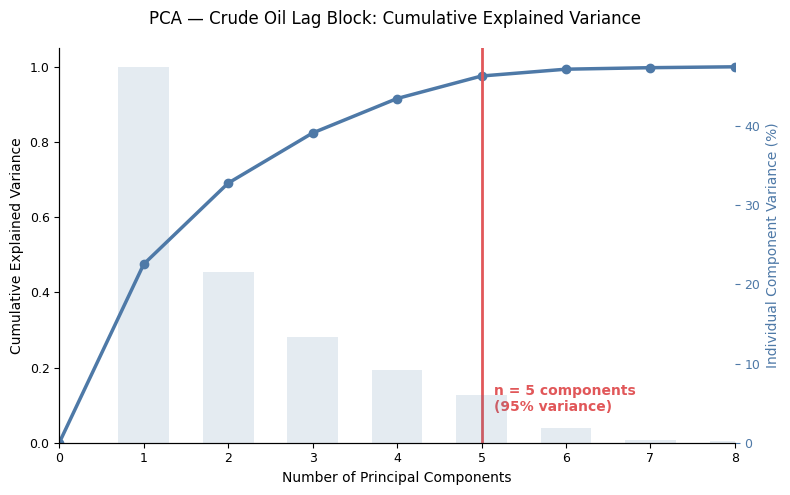

In [16]:
# ── Plot 1: Cumulative explained variance (prof's style) ──────────────────
# Adapted from plot_cum_exp_var in utils.py
def plot_cum_exp_var_oil(exp_var_ratio, tol=0.95):
    exp_var = exp_var_ratio.cumsum()
    thresh  = int(np.argmax(exp_var >= tol)) + 1

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(0, len(exp_var) + 1), [0] + exp_var.tolist(),
            lw=2.5, marker='o', color='#4e79a7', markersize=6)

    ax.axvline(thresh, linestyle='-', lw=2.0, color='#e15759')
    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(thresh + 0.15, 0.08,
        f'n = {thresh} components\n({tol*100:.0f}% variance)',
        color='#e15759', weight='bold', fontsize=10, transform=trans)

    # Individual component bars underneath
    ax2 = ax.twinx()
    ax2.bar(range(1, len(exp_var_ratio)+1), exp_var_ratio * 100,
            color='#4e79a7', alpha=0.15, width=0.6)
    ax2.set_ylabel('Individual Component Variance (%)', fontsize=FONT_AXIS,
                   color='#4e79a7')
    ax2.tick_params(colors='#4e79a7', labelsize=FONT_TICK)

    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, len(exp_var))
    ax.set_xlabel('Number of Principal Components', fontsize=FONT_AXIS)
    ax.set_ylabel('Cumulative Explained Variance', fontsize=FONT_AXIS)
    ax.tick_params(labelsize=FONT_TICK)
    ax.spines['top'].set_visible(False)
    fig.suptitle('PCA — Crude Oil Lag Block: Cumulative Explained Variance')
    plt.tight_layout()
    plt.show()
    return thresh

n_components = plot_cum_exp_var_oil(evr, tol=0.95)


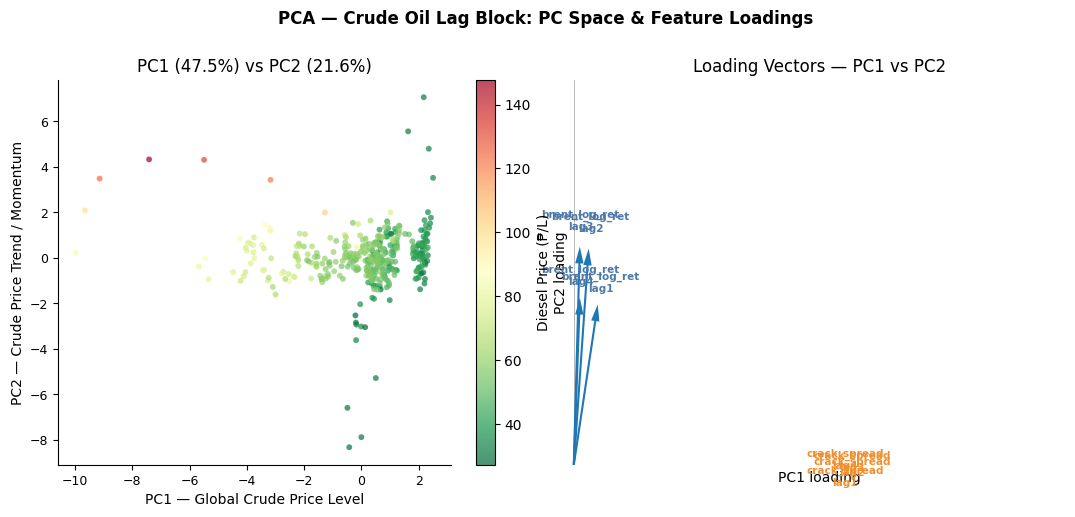

Interpretation:
  PC1 (47.5%): all Brent/Dubai lags load with same sign →
        captures the global crude oil price LEVEL
  PC2 (21.6%): crack_spread loads opposite to Brent/Dubai →
        captures the refining MARGIN (spread between crude and refined)


In [17]:
# ── Plot 2: PC1 vs PC2 scatter — colored by diesel price level ────────────
# This is the interpretive scatter from prof's plot_principal_components style
# We color by diesel price to show what PC1 and PC2 actually capture

diesel_aligned = df.loc[pca_data.index, PRIMARY_TARGET]

fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                         gridspec_kw={'wspace': 0.05})

# Left: PC1 vs PC2 scatter colored by diesel price level
sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=diesel_aligned, cmap='RdYlGn_r',
                     s=18, alpha=0.7, edgecolors='none')
plt.colorbar(sc, ax=axes[0], label='Diesel Price (₱/L)')
axes[0].set_xlabel('PC1 — Global Crude Price Level', fontsize=FONT_AXIS)
axes[0].set_ylabel('PC2 — Crude Price Trend / Momentum', fontsize=FONT_AXIS)
axes[0].set_title(f'PC1 ({evr[0]*100:.1f}%) vs PC2 ({evr[1]*100:.1f}%)')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].tick_params(labelsize=FONT_TICK)

# Right: Loading vectors — which original features drive each PC
W = pd.DataFrame(pca.components_[:2].T,
                 index=crude_lag_block,
                 columns=['PC1', 'PC2'])

palette = sns.color_palette('tab10')
weights = np.linalg.norm(W.values, axis=1)
top_idx = weights.argsort()[-len(crude_lag_block):]  # show all in this case

for i, feat in enumerate(W.index[top_idx]):
    vec = W.loc[feat].values
    axes[1].annotate('', xy=(vec[0], vec[1]), xytext=(0, 0),
                     arrowprops=dict(facecolor=palette[0], edgecolor='none',
                                     width=1.5, headwidth=6))
    # Color label by feature type
    color = '#4e79a7' if 'brent' in feat else             '#e15759' if 'dubai' in feat else '#f28e2b'
    axes[1].text(vec[0]*1.12, vec[1]*1.08, feat.replace('_lag', '\nlag'),
             ha='center', fontsize=7.5, color=color, weight='bold', zorder=10)

axes[1].axhline(0, color='gray', linewidth=0.4)
axes[1].axvline(0, color='gray', linewidth=0.4)
axes[1].set_xlabel('PC1 loading', fontsize=FONT_AXIS)
axes[1].set_ylabel('PC2 loading', fontsize=FONT_AXIS)
axes[1].set_title('Loading Vectors — PC1 vs PC2')
for spine in ['top', 'right', 'left', 'bottom']:
    axes[1].spines[spine].set_visible(False)
axes[1].tick_params(which='both', bottom=False, left=False,
                    labelbottom=False, labelleft=False)

plt.suptitle('PCA — Crude Oil Lag Block: PC Space & Feature Loadings',
             fontsize=FONT_TITLE, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Interpretation:')
print(f'  PC1 ({evr[0]*100:.1f}%): all Brent/Dubai lags load with same sign →')
print(f'        captures the global crude oil price LEVEL')
print(f'  PC2 ({evr[1]*100:.1f}%): crack_spread loads opposite to Brent/Dubai →')
print(f'        captures the refining MARGIN (spread between crude and refined)')


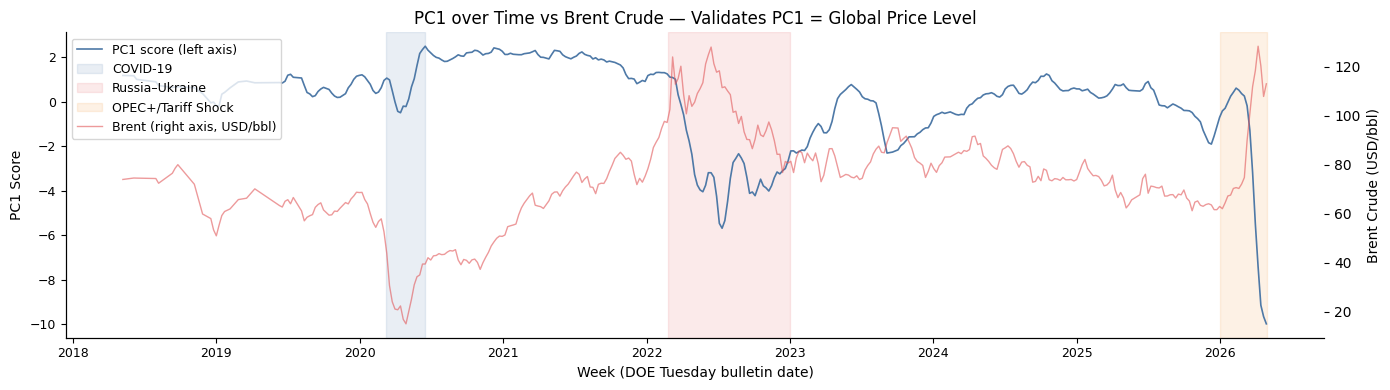

PC1 vs Brent correlation: -0.6247
→ If |r| > 0.90, PC1 is validly interpreted as the global crude price level.


In [18]:
# ── Plot 3: PC1 over time — confirms it tracks crude price level ──────────
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

ax2 = ax.twinx()
ax.plot(pca_data.index, X_pca[:, 0], color='#4e79a7', linewidth=1.2,
        label='PC1 score (left axis)')
ax2.plot(pca_data.index, df.loc[pca_data.index, 'brent_mean'],
         color='#e15759', linewidth=1.0, alpha=0.6,
         label='Brent (right axis, USD/bbl)')
shade_crises(ax)

ax.set_ylabel('PC1 Score', fontsize=FONT_AXIS)
ax2.set_ylabel('Brent Crude (USD/bbl)', fontsize=FONT_AXIS)
ax.set_xlabel('Week (DOE Tuesday bulletin date)', fontsize=FONT_AXIS)
ax.set_title('PC1 over Time vs Brent Crude — Validates PC1 = Global Price Level')

lines1, lbl1 = ax.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lbl1 + lbl2, loc='upper left', fontsize=FONT_LEGEND)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(labelsize=FONT_TICK)
plt.tight_layout()
plt.show()

r_pc1_brent = np.corrcoef(X_pca[:, 0], df.loc[pca_data.index, 'brent_mean'])[0,1]
print(f'PC1 vs Brent correlation: {r_pc1_brent:.4f}')
print('→ If |r| > 0.90, PC1 is validly interpreted as the global crude price level.')


---
## Section 10 — Feature Importance (Random Forest Diagnostic)

Before finalizing the feature set, we run a Random Forest on the **diesel log return target** (not price levels) using lag-1 features. This is a full-sample diagnostic — not the final model — to:
1. Check that momentum features now register (addressing prof's concern)
2. Identify obvious dead weight before PCA components are added

**Target is log return here**, not price level. A feature that strongly predicts *changes* is much more useful than one that just correlates with the level.


In [19]:
# Lag-1 feature matrix for RF diagnostic
all_lag1 = [f for f in df.columns if '_lag1' in f and f in df.columns]
X_rf_data = df[all_lag1 + ['excise_diesel']].dropna()
y_rf_data = df.loc[X_rf_data.index, 'diesel_log_ret'].dropna()

# Align
common_idx = X_rf_data.index.intersection(y_rf_data.index)
X_rf_data  = X_rf_data.loc[common_idx]
y_rf_data  = y_rf_data.loc[common_idx]

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_rf_data, y_rf_data)

imp_df = pd.DataFrame({
    'feature':    X_rf_data.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(30)

print('Top 30 features by RF importance (target = diesel log return):')
print(imp_df.to_string(index=False))


Top 30 features by RF importance (target = diesel log return):
                 feature  importance
        dubai_close_lag1    0.125093
       brent_mom_1w_lag1    0.119435
       crack_spread_lag1    0.076527
            GPR_OIL_lag1    0.072869
       brent_mom_2w_lag1    0.069148
      brent_chg_pos_lag1    0.065661
markov_prob_highvol_lag1    0.064906
      brent_chg_neg_lag1    0.063523
       brent_pct_1w_lag1    0.043918
      brent_log_ret_lag1    0.040200
             diesel_lag1    0.037327
       usd_php_mean_lag1    0.036021
     diesel_log_ret_lag1    0.026481
         brent_mean_lag1    0.025993
           ovx_mean_lag1    0.025393
      diesel_mom_1w_lag1    0.022863
      diesel_mom_2w_lag1    0.019530
      brent_vol_12w_lag1    0.019022
       brent_vol_4w_lag1    0.017877
      usdphp_pct_1w_lag1    0.016327
          cpi_value_lag1    0.009415
           excise_diesel    0.001704
          d_ukraine_lag1    0.000485
            d_covid_lag1    0.000285


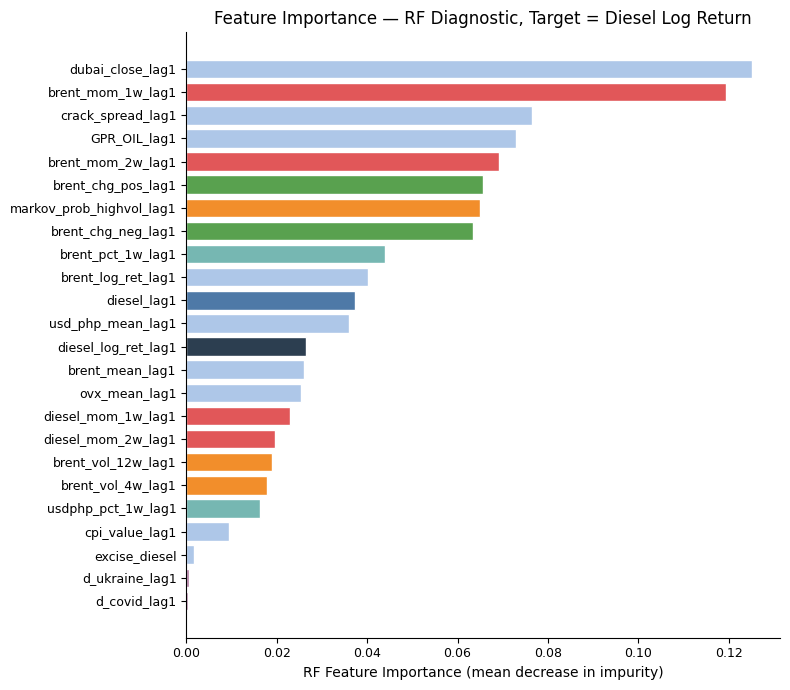


Prof-requested features — do they register?
                 feature  importance
       brent_mom_1w_lag1    0.119435
       brent_mom_2w_lag1    0.069148
      brent_chg_pos_lag1    0.065661
markov_prob_highvol_lag1    0.064906
      brent_chg_neg_lag1    0.063523
       brent_pct_1w_lag1    0.043918
      brent_log_ret_lag1    0.040200
     diesel_log_ret_lag1    0.026481
      diesel_mom_1w_lag1    0.022863
      diesel_mom_2w_lag1    0.019530
      brent_vol_12w_lag1    0.019022
       brent_vol_4w_lag1    0.017877
      usdphp_pct_1w_lag1    0.016327


In [20]:
# ── Feature importance bar chart — colored by family ─────────────────────
def feat_color(name):
    if 'diesel_log_ret' in name: return '#2c3e50'  # target log return lags
    if any(t in name for t in ['diesel_lag', 'diesel_plus', 'kerosene',
                                'ron91', 'ron95', 'ron97']): return '#4e79a7'  # own-price
    if 'mom' in name:           return '#e15759'   # momentum
    if 'vol' in name:           return '#f28e2b'   # volatility
    if 'pct' in name:           return '#76b7b2'   # WoW %
    if 'markov' in name or 'covid' in name or 'ukraine' in name: return '#b07aa1'  # regime
    if 'chg_pos' in name or 'chg_neg' in name:  return '#59a14f'  # RFH
    return '#aec7e8'

colors_imp = [feat_color(f) for f in imp_df['feature']]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
        color=colors_imp[::-1], edgecolor='white')

ax.set_xlabel('RF Feature Importance (mean decrease in impurity)', fontsize=FONT_AXIS)
ax.set_title('Feature Importance — RF Diagnostic, Target = Diesel Log Return')
ax.tick_params(labelsize=FONT_TICK)
plt.tight_layout()
plt.show()

# Check prof-requested features
print('\nProf-requested features — do they register?')
prof_keys = ['mom', 'vol', 'pct', 'markov', 'chg_pos', 'chg_neg', 'log_ret']
prof_imp  = imp_df[[any(k in f for k in prof_keys) for f in imp_df['feature']]]
if len(prof_imp):
    print(prof_imp.to_string(index=False))
else:
    print('None in top 30 — review feature construction.')


---
## Section 11 — Final Diesel Feature Set

We now assemble the final feature set for diesel. The crude lag block is **not** included directly — it enters as PCA components in Notebook 04. Everything else is included directly.

**Structure:**
1. Own-price lags 1–4 (diesel level and diesel log return)
2. p-value selected lag-1 market features
3. Unconditional features (momentum, vol, WoW %, regime, RFH)
4. Excise tax
5. PCA component count for the crude block (for NB04 reference)


In [21]:
# Final diesel feature set (excluding crude lag block — enters as PCA in NB04)
FINAL_DIESEL_FEATURES = list(dict.fromkeys(
    UNCONDITIONAL + sig_feats
))
FINAL_DIESEL_FEATURES = [f for f in FINAL_DIESEL_FEATURES if f in df.columns
                          and f not in crude_lag_block]

print(f'Final diesel feature set: {len(FINAL_DIESEL_FEATURES)} features')
print()
for f in FINAL_DIESEL_FEATURES:
    print(f'  {f}')

print(f'\nCrude lag block ({len(crude_lag_block)} columns) → {n_components} PCA components in NB04')
print(f'Total effective features in NB04: {len(FINAL_DIESEL_FEATURES)} + {n_components} PCA = '
      f'{len(FINAL_DIESEL_FEATURES) + n_components}')


Final diesel feature set: 54 features

  diesel_lag1
  diesel_lag2
  diesel_lag3
  diesel_lag4
  diesel_log_ret_lag1
  diesel_log_ret_lag2
  diesel_log_ret_lag3
  diesel_log_ret_lag4
  diesel_mom_1w_lag1
  diesel_mom_1w_lag2
  diesel_mom_1w_lag3
  diesel_mom_1w_lag4
  diesel_mom_2w_lag1
  diesel_mom_2w_lag2
  diesel_mom_2w_lag3
  diesel_mom_2w_lag4
  brent_mom_1w_lag1
  brent_mom_1w_lag2
  brent_mom_1w_lag3
  brent_mom_1w_lag4
  brent_mom_2w_lag1
  brent_mom_2w_lag2
  brent_mom_2w_lag3
  brent_mom_2w_lag4
  brent_vol_4w_lag1
  brent_vol_4w_lag2
  brent_vol_4w_lag3
  brent_vol_4w_lag4
  brent_vol_12w_lag1
  brent_vol_12w_lag2
  brent_vol_12w_lag3
  brent_vol_12w_lag4
  markov_prob_highvol_lag1
  brent_pct_1w_lag1
  brent_pct_1w_lag2
  brent_pct_1w_lag3
  brent_pct_1w_lag4
  usdphp_pct_1w_lag1
  usdphp_pct_1w_lag2
  usdphp_pct_1w_lag3
  usdphp_pct_1w_lag4
  brent_chg_pos_lag1
  brent_chg_pos_lag2
  brent_chg_pos_lag3
  brent_chg_pos_lag4
  brent_chg_neg_lag1
  brent_chg_neg_lag2
  brent_

---
## Section 12 — Save Outputs

In [22]:
# Save enriched feature dataframe
df.to_parquet('data/final/features_engineered.parquet')
print(f'Saved: features_engineered.parquet — {df.shape}')

# Save diesel feature set definition
feature_config = {
    'diesel': {
        'direct_features':  FINAL_DIESEL_FEATURES,
        'crude_pca_block':  crude_lag_block,
        'n_pca_components': int(n_components),
        'target':           'diesel_log_ret',
        'back_transform':   'price_t = price_{t-1} * exp(log_ret_hat)',
    }
}
with open('data/final/feature_sets.json', 'w') as f:
    json.dump(feature_config, f, indent=2)
print('Saved: feature_sets.json')

# Save PCA scaler + component count for NB04 reference
pca_config = {
    'crude_pca_block':   crude_lag_block,
    'n_components_95pct': int(n_components),
    'note': 'Re-fit StandardScaler + PCA inside each CV fold in NB04. Never on test data.'
}
with open('data/final/pca_config.json', 'w') as f:
    json.dump(pca_config, f, indent=2)
print('Saved: pca_config.json')

print()
print('Decision log:')
print(f'  Modeling target      : diesel_log_ret (stationary, I(1) confirmed by ADF)')
print(f'  MOPS                 : excluded (prof: data leakage)')
print(f'  Derived features     : crack_spread, RFH pos/neg, momentum 1w/2w,')
print(f'                         WoW %, realized vol 4w/12w, Brent log return')
print(f'  Excise               : TRAIN Law RA 10963, 3-tranche step function')
print(f'  Lag structure        : lags 1–4 market | lags 1–4 own-price | lag 1 regime')
print(f'  p-value screening    : {len(sig_feats)} significant from {len(CANDIDATE_LAG1)} candidates')
print(f'  VIF screen           : run — high-VIF crude features handled by PCA')
print(f'  PCA                  : {len(crude_lag_block)} crude lag cols → {n_components} components at 95%')
print(f'  RF diagnostic        : momentum + vol features verified to register')
print(f'  Final feature set    : {len(FINAL_DIESEL_FEATURES)} direct + {n_components} PCA')
print()
print('⚠  NB04 must: (1) re-fit StandardScaler + PCA inside each CV fold on train data only')
print('               (2) back-transform predictions: price_t = price_{t-1} * exp(pred)')
print('               (3) build naive lag-1 baseline FIRST before any ML model')


Saved: features_engineered.parquet — (369, 135)
Saved: feature_sets.json
Saved: pca_config.json

Decision log:
  Modeling target      : diesel_log_ret (stationary, I(1) confirmed by ADF)
  MOPS                 : excluded (prof: data leakage)
  Derived features     : crack_spread, RFH pos/neg, momentum 1w/2w,
                         WoW %, realized vol 4w/12w, Brent log return
  Excise               : TRAIN Law RA 10963, 3-tranche step function
  Lag structure        : lags 1–4 market | lags 1–4 own-price | lag 1 regime
  p-value screening    : 4 significant from 8 candidates
  VIF screen           : run — high-VIF crude features handled by PCA
  PCA                  : 8 crude lag cols → 5 components at 95%
  RF diagnostic        : momentum + vol features verified to register
  Final feature set    : 54 direct + 5 PCA

⚠  NB04 must: (1) re-fit StandardScaler + PCA inside each CV fold on train data only
               (2) back-transform predictions: price_t = price_{t-1} * exp(pred)
   

In [23]:
df

,usd_php_mean,brent_mean,mops_gasoil_mean,mops_rbob_mean,dubai_close,cpi_value,rub_usd_mean,vix_mean,GPR_AI,GPR_OIL,...,diesel_lag2,diesel_lag3,diesel_lag4,diesel_log_ret_lag1,diesel_log_ret_lag2,diesel_log_ret_lag3,diesel_log_ret_lag4,markov_prob_highvol_lag1,d_covid_lag1,d_ukraine_lag1
2018-04-24,52.174800,74.720,84.102200,87.865679,68.667143,98.8,0.016317,16.560000,103.851429,29.570000,...,38.925,38.025,39.175,0.006402,0.023393,-0.029795,NaN,0.011965,0.0,0.0
2018-05-08,51.700800,74.050,86.656000,88.424280,74.077826,99.0,0.015853,15.220000,99.965714,82.907143,...,39.175,38.925,38.025,0.076748,0.006402,0.023393,-0.029795,0.066035,0.0,0.0
2018-06-05,52.514400,74.640,89.137000,90.018600,73.311429,99.4,0.016055,13.794000,110.881429,0.000000,...,42.300,39.175,38.925,0.001771,0.076748,0.006402,0.023393,0.013489,0.0,0.0
2018-06-12,52.596800,74.602,88.484401,88.157158,73.311429,99.4,0.016066,12.128000,110.770000,31.191429,...,42.375,42.300,39.175,0.038199,0.001771,0.076748,0.006402,0.008864,0.0,0.0
2018-07-31,53.148000,74.434,86.858600,90.188282,72.769545,100.2,0.015926,12.910000,106.248571,69.622857,...,44.025,42.375,42.300,-0.013722,0.038199,0.001771,0.076748,0.007731,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-31,60.290199,118.514,190.417001,134.874598,126.706364,127.2,0.012347,27.936000,243.194286,1844.237143,...,103.285,82.000,58.675,0.156023,0.230773,0.334706,0.027035,1.000000,0.0,1.0
2026-04-07,60.249200,128.460,222.210499,136.424400,126.706364,127.2,0.012427,24.590001,257.410000,1684.705714,...,120.725,103.285,82.000,0.085872,0.156023,0.230773,0.334706,0.999826,0.0,1.0
2026-04-14,59.809000,120.436,196.905798,127.674960,126.706364,127.2,0.012912,19.448000,271.377143,1550.767143,...,131.550,120.725,103.285,0.116473,0.085872,0.156023,0.230773,0.999998,0.0,1.0
2026-04-21,59.834400,107.946,188.889404,130.740123,126.706364,127.2,0.013239,18.392000,208.717143,1064.807143,...,147.800,131.550,120.725,-0.178809,0.116473,0.085872,0.156023,1.000000,0.0,1.0


In [24]:
trymoto = pd.read_parquet("data/final/features_engineered.parquet")
trymoto

,usd_php_mean,brent_mean,mops_gasoil_mean,mops_rbob_mean,dubai_close,cpi_value,rub_usd_mean,vix_mean,GPR_AI,GPR_OIL,...,diesel_lag2,diesel_lag3,diesel_lag4,diesel_log_ret_lag1,diesel_log_ret_lag2,diesel_log_ret_lag3,diesel_log_ret_lag4,markov_prob_highvol_lag1,d_covid_lag1,d_ukraine_lag1
2018-04-24,52.174800,74.720,84.102200,87.865679,68.667143,98.8,0.016317,16.560000,103.851429,29.570000,...,38.925,38.025,39.175,0.006402,0.023393,-0.029795,NaN,0.011965,0.0,0.0
2018-05-08,51.700800,74.050,86.656000,88.424280,74.077826,99.0,0.015853,15.220000,99.965714,82.907143,...,39.175,38.925,38.025,0.076748,0.006402,0.023393,-0.029795,0.066035,0.0,0.0
2018-06-05,52.514400,74.640,89.137000,90.018600,73.311429,99.4,0.016055,13.794000,110.881429,0.000000,...,42.300,39.175,38.925,0.001771,0.076748,0.006402,0.023393,0.013489,0.0,0.0
2018-06-12,52.596800,74.602,88.484401,88.157158,73.311429,99.4,0.016066,12.128000,110.770000,31.191429,...,42.375,42.300,39.175,0.038199,0.001771,0.076748,0.006402,0.008864,0.0,0.0
2018-07-31,53.148000,74.434,86.858600,90.188282,72.769545,100.2,0.015926,12.910000,106.248571,69.622857,...,44.025,42.375,42.300,-0.013722,0.038199,0.001771,0.076748,0.007731,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-31,60.290199,118.514,190.417001,134.874598,126.706364,127.2,0.012347,27.936000,243.194286,1844.237143,...,103.285,82.000,58.675,0.156023,0.230773,0.334706,0.027035,1.000000,0.0,1.0
2026-04-07,60.249200,128.460,222.210499,136.424400,126.706364,127.2,0.012427,24.590001,257.410000,1684.705714,...,120.725,103.285,82.000,0.085872,0.156023,0.230773,0.334706,0.999826,0.0,1.0
2026-04-14,59.809000,120.436,196.905798,127.674960,126.706364,127.2,0.012912,19.448000,271.377143,1550.767143,...,131.550,120.725,103.285,0.116473,0.085872,0.156023,0.230773,0.999998,0.0,1.0
2026-04-21,59.834400,107.946,188.889404,130.740123,126.706364,127.2,0.013239,18.392000,208.717143,1064.807143,...,147.800,131.550,120.725,-0.178809,0.116473,0.085872,0.156023,1.000000,0.0,1.0


In [25]:
# ── Define the complete, clean feature matrix for NB04 ───────────────────
# Everything NB04 needs: direct features + crude lag block for PCA
# Nothing NB04 doesn't need: raw MOPS, WTI, intermediates, other products

COLS_TO_SAVE = list(dict.fromkeys(
    [PRIMARY_TARGET, 'diesel_log_ret']  # target and back-transform anchor
    + FINAL_DIESEL_FEATURES             # curated direct features
    + crude_lag_block                   # raw crude lags → PCA in NB04
))
COLS_TO_SAVE = [c for c in COLS_TO_SAVE if c in df.columns]

df_save = df[COLS_TO_SAVE].copy()

print(f'Saving {len(COLS_TO_SAVE)} columns (trimmed from {df.shape[1]}):')
for c in COLS_TO_SAVE:
    print(f'  {c}')

df_save.to_parquet('data/final/features_engineered.parquet')
print(f'\nSaved: features_engineered.parquet — {df_save.shape}')

Saving 64 columns (trimmed from 135):
  diesel
  diesel_log_ret
  diesel_lag1
  diesel_lag2
  diesel_lag3
  diesel_lag4
  diesel_log_ret_lag1
  diesel_log_ret_lag2
  diesel_log_ret_lag3
  diesel_log_ret_lag4
  diesel_mom_1w_lag1
  diesel_mom_1w_lag2
  diesel_mom_1w_lag3
  diesel_mom_1w_lag4
  diesel_mom_2w_lag1
  diesel_mom_2w_lag2
  diesel_mom_2w_lag3
  diesel_mom_2w_lag4
  brent_mom_1w_lag1
  brent_mom_1w_lag2
  brent_mom_1w_lag3
  brent_mom_1w_lag4
  brent_mom_2w_lag1
  brent_mom_2w_lag2
  brent_mom_2w_lag3
  brent_mom_2w_lag4
  brent_vol_4w_lag1
  brent_vol_4w_lag2
  brent_vol_4w_lag3
  brent_vol_4w_lag4
  brent_vol_12w_lag1
  brent_vol_12w_lag2
  brent_vol_12w_lag3
  brent_vol_12w_lag4
  markov_prob_highvol_lag1
  brent_pct_1w_lag1
  brent_pct_1w_lag2
  brent_pct_1w_lag3
  brent_pct_1w_lag4
  usdphp_pct_1w_lag1
  usdphp_pct_1w_lag2
  usdphp_pct_1w_lag3
  usdphp_pct_1w_lag4
  brent_chg_pos_lag1
  brent_chg_pos_lag2
  brent_chg_pos_lag3
  brent_chg_pos_lag4
  brent_chg_neg_lag1
  br